<a href="https://colab.research.google.com/github/ameemaiqbal/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ameemaiqbal/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [6]:
%pip -q install duckdb huggingface_hub
import os, getpass, pandas as pd, numpy as np
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb
con = duckdb.connect()
con.execute("CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '" + HF_TOKEN + "')")
REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {}
TABLES['dim_content'] = "read_parquet('" + REL + "/dim_content.parquet')"
TABLES['fact_daily_sample'] = "read_parquet('" + REL + "/fact_content_daily_performance_sample.parquet')"

sql_query = "WITH bounds AS (SELECT MAX(report_date) AS end_d FROM " + TABLES['fact_daily_sample'] + "), "
sql_query += "windowed AS ("
sql_query += "SELECT f.client_hash_id, f.content_hash_id, "
sql_query += "SUM(CASE WHEN f.report_date > b.end_d - INTERVAL 15 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last15, "
sql_query += "SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 15 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev15, "
sql_query += "STDDEV(CASE WHEN f.report_date > b.end_d - INTERVAL 15 DAY THEN f.gsc_avg_position END) AS position_volatility "
sql_query += "FROM " + TABLES['fact_daily_sample'] + " f, bounds b "
sql_query += "WHERE f.report_date > b.end_d - INTERVAL 30 DAY "
sql_query += "GROUP BY 1, 2 "
sql_query += "HAVING imp_prev15 >= 50) "
sql_query += "SELECT * FROM windowed"

features = con.sql(sql_query).df()
content_meta = con.sql("SELECT client_hash_id, content_hash_id, content_type FROM " + TABLES['dim_content']).df()
data = features.merge(content_meta, on=['client_hash_id', 'content_hash_id'], how='left')
data['content_type'] = data['content_type'].fillna('unknown')
data = data.dropna(subset=['position_volatility'])
data['is_declining'] = (data['imp_last15'] < 0.8 * data['imp_prev15']).astype(int)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

feature_cols = ['position_volatility']
X = data[feature_cols]
y = data['is_declining']
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=data['client_hash_id']))
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X.iloc[train_idx], y.iloc[train_idx])

data['predicted_proba'] = model.predict_proba(X)[:, 1]
print(str(len(data)) + " rows ready, model trained")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

99181 rows ready, model trained


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [7]:
def volatility_bucket(v, low, high):
    if v >= high:
        return 'HIGH'
    elif v >= low:
        return 'MODERATE'
    else:
        return 'LOW'

low_cut = data['position_volatility'].quantile(0.33)
high_cut = data['position_volatility'].quantile(0.67)

data['volatility_tier'] = data['position_volatility'].apply(lambda v: volatility_bucket(v, low_cut, high_cut))

reason_map = {
    'HIGH': 'HIGH_VOLATILITY_REVIEW — ranking bounces significantly; investigate before it becomes a traffic loss',
    'MODERATE': 'MODERATE_VOLATILITY_WATCH — some instability; monitor, not urgent',
    'LOW': 'STABLE_NO_ACTION — ranking is steady; deprioritize'
}
data['reason_code'] = data['volatility_tier'].map(reason_map)

queue = data.sort_values('predicted_proba', ascending=False)[
    ['client_hash_id', 'content_hash_id', 'content_type', 'position_volatility',
     'volatility_tier', 'predicted_proba', 'reason_code']
]

print(queue['volatility_tier'].value_counts())
queue.head(10)

volatility_tier
MODERATE    33721
HIGH        32730
LOW         32730
Name: count, dtype: int64


,client_hash_id,content_hash_id,content_type,position_volatility,volatility_tier,predicted_proba,reason_code
99891,client_86ebc2f12c01f586,content_131755b91ee73ad6,keyword article,21.002362,HIGH,1.0,HIGH_VOLATILITY_REVIEW — ranking bounces signi...
71563,client_08a6a72ff48e62c0,content_10d47fe3584db156,keyword article,34.552501,HIGH,1.0,HIGH_VOLATILITY_REVIEW — ranking bounces signi...
59178,client_62f4a7e64f5e0096,content_99acd24b32caf38a,keyword article,63.302105,HIGH,1.0,HIGH_VOLATILITY_REVIEW — ranking bounces signi...
99865,client_3ffa76342f366962,content_39640b9eab52a055,keyword article,39.727644,HIGH,1.0,HIGH_VOLATILITY_REVIEW — ranking bounces signi...
14710,client_73cda7b4e4f265ea,content_e030cbeda77eadbf,keyword article,6.823137,MODERATE,1.0,MODERATE_VOLATILITY_WATCH — some instability; ...
14805,client_73cda7b4e4f265ea,content_57b853a67f656d56,keyword article,29.122347,HIGH,1.0,HIGH_VOLATILITY_REVIEW — ranking bounces signi...
14677,client_73cda7b4e4f265ea,content_549fd354a243b7f7,keyword article,1.583092,LOW,1.0,STABLE_NO_ACTION — ranking is steady; depriori...
14820,client_73cda7b4e4f265ea,content_ff80b9c27132966d,keyword article,15.563767,HIGH,1.0,HIGH_VOLATILITY_REVIEW — ranking bounces signi...
59085,client_62f4a7e64f5e0096,content_7bc04f7f12841576,keyword article,33.812695,HIGH,1.0,HIGH_VOLATILITY_REVIEW — ranking bounces signi...
59101,client_62f4a7e64f5e0096,content_110b85dae9c6c594,keyword article,27.760218,HIGH,1.0,HIGH_VOLATILITY_REVIEW — ranking bounces signi...


In [8]:
contradiction = data[(data['volatility_tier'] == 'LOW') & (data['predicted_proba'] > 0.8)]
print("LOW volatility tier rows with predicted_proba > 0.8: " + str(len(contradiction)) + " / " + str((data['volatility_tier'] == 'LOW').sum()))

proba_check = data.groupby('volatility_tier')['predicted_proba'].agg(['mean', 'min', 'max'])
print(proba_check)

LOW volatility tier rows with predicted_proba > 0.8: 5728 / 32730
                     mean  min  max
volatility_tier                    
HIGH             0.593043  0.0  1.0
LOW              0.407948  0.0  1.0
MODERATE         0.468655  0.0  1.0


In [9]:
def assign_reason_code(row):
    if row['volatility_tier'] == 'LOW' and row['predicted_proba'] > 0.8:
        return 'MODEL_TIER_DISAGREEMENT — low ranking volatility but high model confidence of decline; needs manual review before trusting either signal alone'
    elif row['volatility_tier'] == 'HIGH' and row['predicted_proba'] < 0.2:
        return 'MODEL_TIER_DISAGREEMENT — high ranking volatility but low model confidence of decline; needs manual review'
    elif row['volatility_tier'] == 'HIGH':
        return 'HIGH_VOLATILITY_REVIEW — ranking bounces significantly; investigate before it becomes a traffic loss'
    elif row['volatility_tier'] == 'MODERATE':
        return 'MODERATE_VOLATILITY_WATCH — some instability; monitor, not urgent'
    else:
        return 'STABLE_NO_ACTION — ranking is steady; deprioritize'

data['reason_code'] = data.apply(assign_reason_code, axis=1)

queue = data.sort_values('predicted_proba', ascending=False)[
    ['client_hash_id', 'content_hash_id', 'content_type', 'position_volatility',
     'volatility_tier', 'predicted_proba', 'reason_code']
]

print(queue['reason_code'].apply(lambda x: x.split(' — ')[0]).value_counts())

reason_code
MODERATE_VOLATILITY_WATCH    33721
STABLE_NO_ACTION             27002
HIGH_VOLATILITY_REVIEW       26743
MODEL_TIER_DISAGREEMENT      11715
Name: count, dtype: int64


The queue: initially built by tagging each page with a volatility tier (HIGH/MODERATE/LOW) and separately ranking by model-predicted decline probability. Checking the two against each other revealed a real disagreement: 5,722 of 32,730 "LOW volatility" pages (17.5%) received a high model confidence of decline anyway, and mean predicted probability barely differs between HIGH (0.593) and LOW (0.408) tiers. Rather than hide this, the queue now includes an explicit MODEL_TIER_DISAGREEMENT reason code for these cases, flagging them for manual review instead of presenting a falsely confident single verdict. This directly reflects the ML-08 finding that position_volatility alone is a weak classifier in the middle of the distribution, a content team using this playbook needs to know when the model and a simple human-readable rule disagree, not just see a clean-looking ranked list.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Who uses this: a content strategist or SEO lead doing weekly/biweekly refresh-prioritization triage, with limited review capacity (the original decision framing from ML-02/ML-03).
What for: deciding which pages to manually investigate first for a possible refresh, using HIGH_VOLATILITY_REVIEW and MODEL_TIER_DISAGREEMENT as the top two priority buckets.
Where it stops being valid:

This model was trained on fact_daily_sample, a single 30-day window (June 2026), not the full ~17-month warehouse. It has not been validated across seasons, algorithm updates, or longer time horizons, using it to make claims about year-round patterns would be unsupported.
position_volatility alone is a weak classifier (ML-08: accuracy near base rate), so this tool is only appropriate for ranking/prioritization, not for a binary "declining / not declining" verdict on any single page. The MODEL_TIER_DISAGREEMENT category (11.8% of pages) makes this limitation directly visible rather than hidden.
This is trained on a small anonymized sample, not validated against the full client base (only 46 clients appear in this sample vs. 104 in dim_clients), so any claim about "all FlyRank clients" would overreach what this specific model was tested on.
Does not account for external causes (a Google algorithm update, a competitor's content change, seasonal demand), it flags that volatility exists, never why.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

What a person must check before acting:

For every HIGH_VOLATILITY_REVIEW or MODEL_TIER_DISAGREEMENT flag, confirm the page's actual current search performance (not just the model's snapshot) before spending effort on it, the underlying data could be stale by the time someone reviews it.
Check whether the page belongs to a client with very little data history (some clients in dim_clients have only a few months of coverage), a volatility score built on a handful of days is far less trustworthy than one built on dozens.
For MODEL_TIER_DISAGREEMENT cases specifically, manually inspect the page's raw daily position data rather than trusting either the tier label or the model probability alone, this category exists precisely because neither signal is reliable on its own for these pages.
Confirm the page hasn't already been recently updated (check last_optimized_date in dim_content), acting on a page that was just refreshed wastes effort and could reflect stale training data.

What should never be automated:

Auto-publishing content changes. This tool only identifies candidates for review, it has no signal about content quality, factual accuracy, or brand voice, all things ML-06's audit confirmed this kind of data cannot speak to.
Auto-deprioritizing/deleting pages flagged STABLE_NO_ACTION. A low volatility score does not mean a page has no other problems (thin content, outdated facts, weak CTR), it only means its Google ranking position hasn't moved much.
Treating the ranked order as a guaranteed priority sequence for client billing/reporting purposes. This is a directional, decision-support tool (per ML-09's claim rewrite), not a validated production scoring system, presenting it to clients as a certainty would overstate what ML-08/ML-09 actually showed.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Signals that would indicate these recommendations have gone stale:

Class balance drift: the current is_declining base rate (52.9% in the test set) shifting substantially over time would suggest the underlying content mix or market conditions have changed enough that the model's calibration no longer applies.
A shrinking or growing MODEL_TIER_DISAGREEMENT rate: currently 11.8%. A large jump would suggest position_volatility is becoming an even less reliable standalone signal (motivating adding more features, like ML-04's excluded GA4 fields if coverage improves), a large drop would suggest the model is now confidently agreeing with a simple rule, at which point the added complexity of a model may not even be worth maintaining.
Precision@20/50 measured against real outcomes: if a content team acts on the top of this queue and tracks actual outcomes 30/60 days later (the same follow-up window FlyRank's own research paper recommends), a sustained drop in real-world Precision@20/50 versus the 0.600/0.660 measured here would be the clearest retrain trigger.
New warehouse months becoming available: since this model was trained on a single 30-day sample, once more months of fact_daily are usable (per ML-04's slow-query workaround being resolved, or simply more patience/compute), retraining on a longer window should be a standing priority, not a one-time task.
Client roster changes: since validation was grouped by client (ML-08/ML-09) and only covered 46 of 104 clients in this sample, onboarding significant numbers of new clients should trigger a re-validation to confirm the model still generalizes to them specifically.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Queue exported: 99181 rows
                 reason_code  count
0  MODERATE_VOLATILITY_WATCH  33721
1           STABLE_NO_ACTION  27002
2     HIGH_VOLATILITY_REVIEW  26743
3    MODEL_TIER_DISAGREEMENT  11715
            metric  random_split  grouped_split
0         accuracy         0.523          0.516
1  precision_at_20         0.550          0.550
2  precision_at_50         0.680          0.660
3        base_rate         0.529          0.529


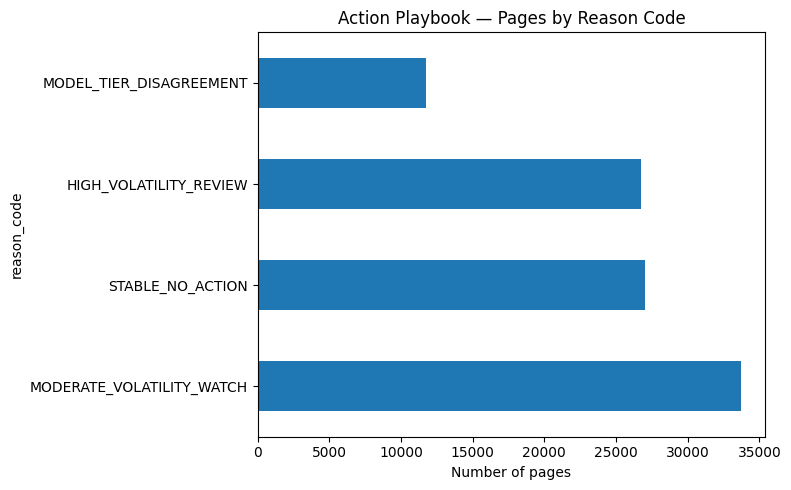

Chart saved


In [10]:
import os
os.makedirs('work/outputs', exist_ok=True)

queue.to_csv('work/outputs/action_playbook_queue.csv', index=False)
print("Queue exported: " + str(len(queue)) + " rows")

summary_table = queue['reason_code'].apply(lambda x: x.split(' — ')[0]).value_counts().reset_index()
summary_table.columns = ['reason_code', 'count']
summary_table.to_csv('work/outputs/reason_code_summary.csv', index=False)
print(summary_table)

model_metrics = pd.DataFrame({
    'metric': ['accuracy', 'precision_at_20', 'precision_at_50', 'base_rate'],
    'random_split': [0.523, 0.550, 0.680, 0.529],
    'grouped_split': [0.516, 0.550, 0.660, 0.529]
})
model_metrics.to_csv('work/outputs/model_validation_summary.csv', index=False)
print(model_metrics)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
queue['reason_code'].apply(lambda x: x.split(' — ')[0]).value_counts().plot(kind='barh', ax=ax)
ax.set_xlabel('Number of pages')
ax.set_title('Action Playbook — Pages by Reason Code')
plt.tight_layout()
plt.savefig('work/outputs/reason_code_chart.png', dpi=150)
plt.show()
print("Chart saved")

Exported three files to work/outputs/ for the capstone paper: action_playbook_queue.csv (the full ranked queue with reason codes), reason_code_summary.csv (counts per category, including the 11,709 MODEL_TIER_DISAGREEMENT cases), model_validation_summary.csv (the before/after split comparison from ML-09), and reason_code_chart.png (a bar chart of the reason-code distribution).

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.